# GPU Accelerated 2D Heat Diffusion Solver

Problem 5: PDE Solver using GPU

Objective:
Implement a 2D Heat Diffusion Equation on CPU and GPU using CUDA (Numba) and compare performance.

In [ ]:
!nvidia-smi

In [ ]:
from numba import cuda

print(cuda.is_available())

**Imports**

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import time
from numba import cuda

**Create Initial Grid**

In [4]:
N = 512

grid = np.zeros((N, N), dtype=np.float32)

# Hot spot in center
grid[N//2, N//2] = 100.0

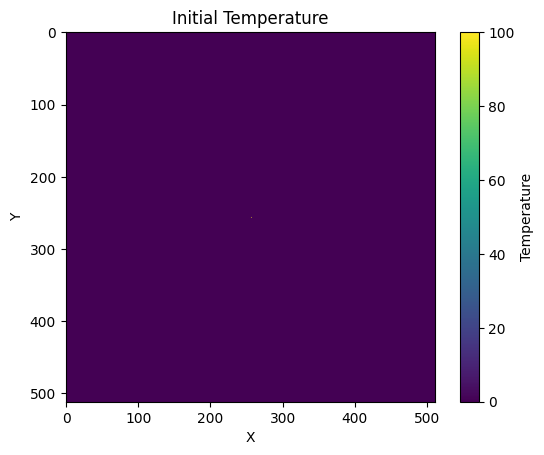

In [15]:
plt.imshow(grid)
plt.colorbar(label="Temperature")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Initial Temperature")
plt.show()

**CPU Heat Diffusion Solver**

In [6]:
def heat_cpu(grid, alpha, steps):

    n, m = grid.shape

    for _ in range(steps):

        new_grid = grid.copy()

        for i in range(1, n-1):
            for j in range(1, m-1):

                new_grid[i, j] = (
                    grid[i, j]
                    + alpha * (
                        grid[i+1, j]
                        + grid[i-1, j]
                        + grid[i, j+1]
                        + grid[i, j-1]
                        - 4 * grid[i, j]
                    )
                )

        grid = new_grid

    return grid

**GPU Kernel**

In [7]:
@cuda.jit
def heat_kernel(old_grid, new_grid, alpha):

    row, col = cuda.grid(2)

    n, m = old_grid.shape

    if 1 <= row < n-1 and 1 <= col < m-1:

        new_grid[row, col] = (
            old_grid[row, col]
            + alpha * (
                old_grid[row+1, col]
                + old_grid[row-1, col]
                + old_grid[row, col+1]
                + old_grid[row, col-1]
                - 4 * old_grid[row, col]
            )
        )

**GPU Driver Function**

In [8]:
def heat_gpu(grid, alpha, steps):

    d_old = cuda.to_device(grid)

    d_new = cuda.device_array_like(grid)

    threads = (16, 16)

    blocks = (
        (grid.shape[0] + 15) // 16,
        (grid.shape[1] + 15) // 16
    )

    for _ in range(steps):

        heat_kernel[blocks, threads](
            d_old,
            d_new,
            alpha
        )

        d_old, d_new = d_new, d_old

    return d_old.copy_to_host()

**BenchMark**

In [9]:
alpha = 0.1
steps = 500

**CPU**

In [10]:
start = time.time()

cpu_result = heat_cpu(
    grid.copy(),
    alpha,
    steps
)

cpu_time = time.time() - start

print("CPU Time:", cpu_time)

CPU Time: 217.11959624290466


**GPU**

In [12]:
start = time.time()

gpu_result = heat_gpu(
    grid.copy(),
    alpha,
    steps
)

cuda.synchronize()

gpu_time = time.time() - start

print("GPU Time:", gpu_time)

GPU Time: 2.324209451675415


**Speedup**

In [13]:
print("Speedup =", cpu_time / gpu_time)

Speedup = 93.41653614152253


**Final Visualisation**

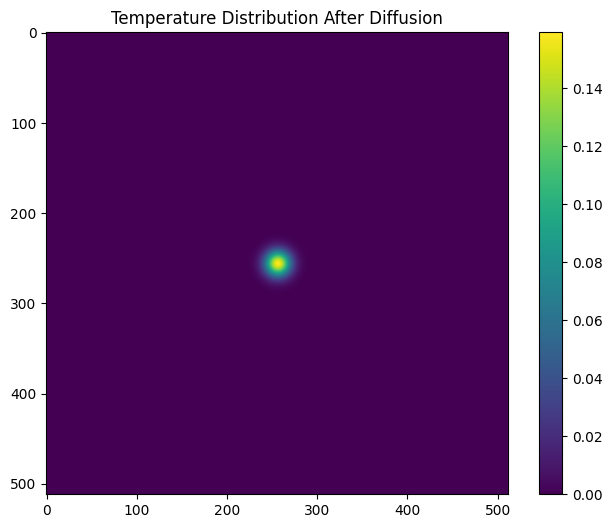

In [14]:
plt.figure(figsize=(8,6))

plt.imshow(gpu_result)

plt.colorbar()

plt.title("Temperature Distribution After Diffusion")

plt.show()